[Современные сверточные сети](https://d2l.ai/chapter_convolutional-modern/index.html "Дополнительный материал")

[Материалы по теме](https://github.com/netology-ds-team/DLL/tree/main/DLL-materials "Учебные блокноты с ГидХаба")

In [ ]:
import torch, pandas as pd, numpy as np, time
import matplotlib.pyplot as plt
import random
import torchvision as tv

## Загрузка данных

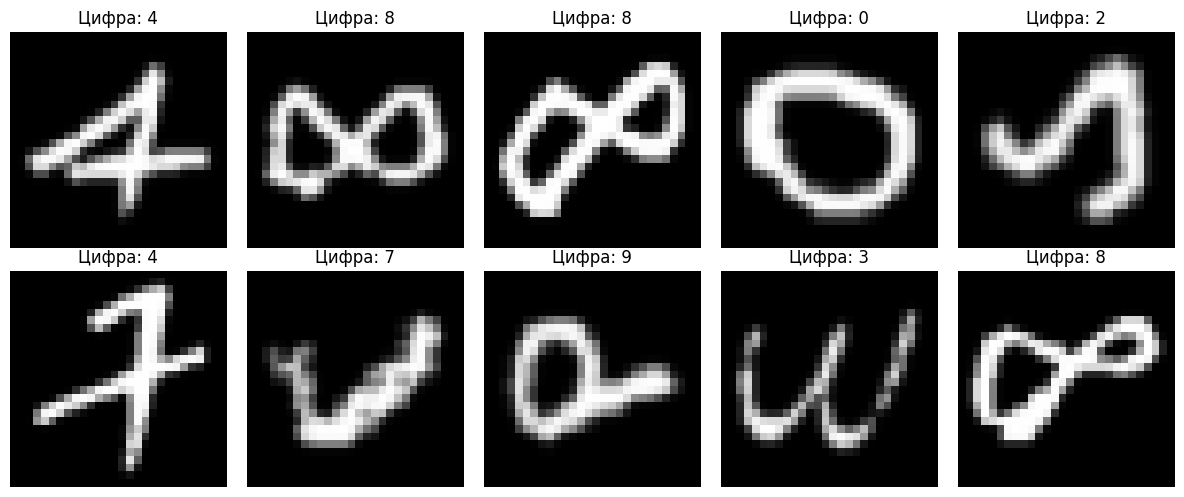

In [ ]:
import torchvision.datasets as datasets
# Загрузка EMNIST (цифры) без преобразований
digits_emnist = datasets.EMNIST(
    root='./data',
    split='digits',
    train=True,
    download=True,
    transform=None  # Без преобразований
)

# Названия классов для EMNIST split='digits' (цифры 0–9)
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# 10 случайных индексов
random_indices = random.sample(range(len(digits_emnist)), 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Отображение выбранных изображений
for i, idx in enumerate(random_indices):
    img, label = digits_emnist[idx]
    # Преобразуем PIL изображение в массив numpy
    img_np = np.array(img)

    # Отображение изображения
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"Цифра: {class_names[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# В случаи если требуется изменить размерность изображений: Подготовка трансформера(в данном случае получение тензора 224*224 и тремя каналами)
transoforms = tv.transforms.Compose([
    tv.transforms.Grayscale(3),
    tv.transforms.Resize((224, 224)),
    tv.transforms.ToTensor()
])

In [ ]:
# dataset без трансформации.
train_dataset = tv.datasets.EMNIST('.', train=True, transform=tv.transforms.ToTensor(), download=True, split='digits')
test_dataset = tv.datasets.EMNIST('.', train=False, transform=tv.transforms.ToTensor(), download=True, split='digits')

In [ ]:
train_Loader = torch.utils.data.DataLoader(train_dataset, batch_size=256)
test_Loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

In [ ]:
for images, labels in train_Loader:
  print(f"Размер батча: {images.shape}")
  print(f"Размер одного изображения: {images[0].shape}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_Loader)}\n'
      f'Общее количество изображений в датасете: {len(train_Loader.dataset)}\n')

Размер батча: torch.Size([256, 1, 28, 28])
Размер одного изображения: torch.Size([1, 28, 28])
Общее количество батчей: 938
Общее количество изображений в датасете: 240000



##ResNet 18

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model_ResNet_18 = tv.models.resnet18(pretrained=False) #  не предобученная модель!

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
from torchsummary import summary

In [ ]:
summary(model_ResNet_18.to(device), input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

Изменил первый слой для изображении 28*28 + последний слой на 10 классов

In [ ]:
model_ResNet_18.conv1 = torch.nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)  # для 28×28, 1 канал. Было: conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model_ResNet_18.fc = torch.nn.Linear(512, 10)  # заменяем последний слой на 10 классов

In [ ]:
summary(model_ResNet_18.to(device), input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
       BatchNorm2d-2           [-1, 64, 28, 28]             128
              ReLU-3           [-1, 64, 28, 28]               0
         MaxPool2d-4           [-1, 64, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]          36,864
       BatchNorm2d-6           [-1, 64, 14, 14]             128
              ReLU-7           [-1, 64, 14, 14]               0
            Conv2d-8           [-1, 64, 14, 14]          36,864
       BatchNorm2d-9           [-1, 64, 14, 14]             128
             ReLU-10           [-1, 64, 14, 14]               0
       BasicBlock-11           [-1, 64, 14, 14]               0
           Conv2d-12           [-1, 64, 14, 14]          36,864
      BatchNorm2d-13           [-1, 64, 14, 14]             128
             ReLU-14           [-1, 64,

In [ ]:
# Фнкция потерь. Она автоматически применяет softmax к выходам модели (не нужно делать это отдельно)
loss = torch.nn.CrossEntropyLoss()

In [ ]:
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [ ]:
def train_model(model, optimizer_, num_epochs=10):
    train_losses = []
    val_losses = []

    # Определяем устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)  # Перемещаем модель на устройство

    for ep in range(num_epochs):
        # Обучение (train)
        train_iters, train_passed = 0, 0
        train_loss, train_acc = 0., 0.
        start = time.time()

        model.train()
        for X, y in train_Loader: # ДАННЫЕ ДЛЯ ОБУЧЕНИЯ
            X = X.to(device)  # Переносим на устройство
            y = y.to(device)  # Переносим на устройство

            optimizer_.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            optimizer_.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)

        # Валидация (test)
        test_iters, test_passed = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        with torch.no_grad():  # Отключаем вычисление градиентов
            for X, y in test_Loader:      # ТЕСТОВЫЕ ДАННЫЕ
                X = X.to(device)  # Обязательно переносим на устройство!
                y = y.to(device)  # Обязательно переносим на устройство!

                y_pred = model(X)
                l = loss(y_pred, y)
                test_loss += l.item()
                test_acc += (y_pred.argmax(dim=1) == y).sum().item()
                test_iters += 1
                test_passed += len(X)

        # Усредняем потери
        avg_train_loss = train_loss / train_iters
        avg_test_loss = test_loss / test_iters

        train_losses.append(avg_train_loss)
        val_losses.append(avg_test_loss)

        print("ep: {}, taked: {:.3f}, train_loss: {:.4f}, train_acc: {:.4f}, test_loss: {:.4f}, test accuracy: {:.4f}".format(
            ep,
            time.time() - start,
            avg_train_loss,
            train_acc / train_passed,
            avg_test_loss,
            test_acc / test_passed
        ))

    return train_losses, val_losses


In [ ]:
trainer_1 = optimizer(model=model_ResNet_18, lr=0.001)

In [ ]:
import pickle
import json

# ОБУЧЕНИЕ
train_losses, val_losses = train_model(
    model=model_ResNet_18,
    optimizer_=trainer_1,
    num_epochs=10
)

# 1. Сохранение в pickle
with open('results_model_ResNet_18.pkl', 'wb') as f:
    pickle.dump({
        'train_losses': train_losses,
        'val_losses': val_losses
    }, f)

# 2. Сохранение в JSON
with open('results_model_ResNet_18.json', 'w') as f:
    json.dump({
        'train_losses': train_losses,
        'val_losses': val_losses
    }, f, indent=4)

ep: 0, taked: 108.119, train_loss: 0.0437, train_acc: 0.9870, test_loss: 0.0271, test accuracy: 0.9919
ep: 1, taked: 107.262, train_loss: 0.0203, train_acc: 0.9943, test_loss: 0.0349, test accuracy: 0.9895
ep: 2, taked: 107.088, train_loss: 0.0164, train_acc: 0.9952, test_loss: 0.0278, test accuracy: 0.9920
ep: 3, taked: 107.074, train_loss: 0.0139, train_acc: 0.9961, test_loss: 0.0214, test accuracy: 0.9940
ep: 4, taked: 106.991, train_loss: 0.0118, train_acc: 0.9968, test_loss: 0.0253, test accuracy: 0.9933
ep: 5, taked: 107.466, train_loss: 0.0105, train_acc: 0.9971, test_loss: 0.0192, test accuracy: 0.9950
ep: 6, taked: 107.146, train_loss: 0.0087, train_acc: 0.9977, test_loss: 0.0209, test accuracy: 0.9949
ep: 7, taked: 107.465, train_loss: 0.0076, train_acc: 0.9979, test_loss: 0.0231, test accuracy: 0.9948
ep: 8, taked: 106.970, train_loss: 0.0068, train_acc: 0.9981, test_loss: 0.0269, test accuracy: 0.9929
ep: 9, taked: 106.663, train_loss: 0.0063, train_acc: 0.9982, test_loss: 

## Результаты обучения модели(графики лосса) + создание таблицы

In [ ]:
import json

with open('results_model_ResNet_18.json', 'r') as f:
    results = json.load(f)

# Преобразуем в DataFrame для удобного просмотра
df_model_ResNet_18 = pd.DataFrame({
    'Epoch': range(len(results['train_losses'])),
    'Train Loss': results['train_losses'],
    'Validation Loss': results['val_losses']
})

df_model_ResNet_18

,Epoch,Train Loss,Validation Loss
0,0,0.043695,0.027141
1,1,0.020288,0.034916
2,2,0.016366,0.027791
3,3,0.013937,0.021431
4,4,0.011762,0.025301
5,5,0.010470,0.019156
6,6,0.008695,0.020938
7,7,0.007555,0.023145
8,8,0.006753,0.026862
9,9,0.006335,0.020248


In [ ]:
def chart_plot(df):
  plt.figure(figsize=(10, 6))
  plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o')
  plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

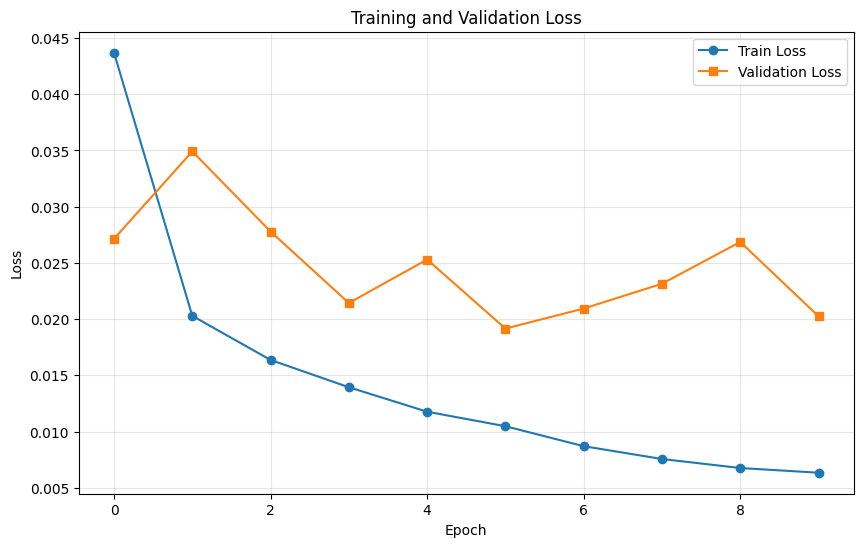

In [ ]:
chart_plot(df_model_ResNet_18)

### Модернизированный график

In [ ]:
def chart_modern_plot(df):
  # Определение лучшей эпохи (минимальная валидационная потеря)
  best_epoch_idx = df['Validation Loss'].idxmin()
  best_epoch = df.loc[best_epoch_idx, 'Epoch']
  best_val_loss = df.loc[best_epoch_idx, 'Validation Loss']

  plt.figure(figsize=(12, 8))

  # Основной график
  plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o', color='blue', alpha=0.7)
  plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s', color='red', alpha=0.7)

  # Выделение лучшей эпохи
  plt.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5, edgecolors='black', linewidth=2)
  plt.annotate(
      f'Best: epoch {int(best_epoch)}\nVal Loss: {best_val_loss:.4f}',
      xy=(best_epoch, best_val_loss),
      xytext=(best_epoch + 1, best_val_loss + 0.05),
      arrowprops=dict(arrowstyle='->', color='black'),
      fontsize=10,
      ha='left'
  )

  # Настройки
  plt.title('Ход обучения с указанием наилучшей эпохи', fontsize=16, fontweight='bold')
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend(fontsize=11)
  plt.grid(True, alpha=0.3, linestyle='--')
  plt.xticks(df['Epoch'])
  plt.tight_layout()
  plt.show()

  # Выводим информацию о лучшей эпохе
  print(f"Лучшая эпоха: {int(best_epoch)}")
  print(f"Минимальная валидационная потеря: {best_val_loss:.4f}")

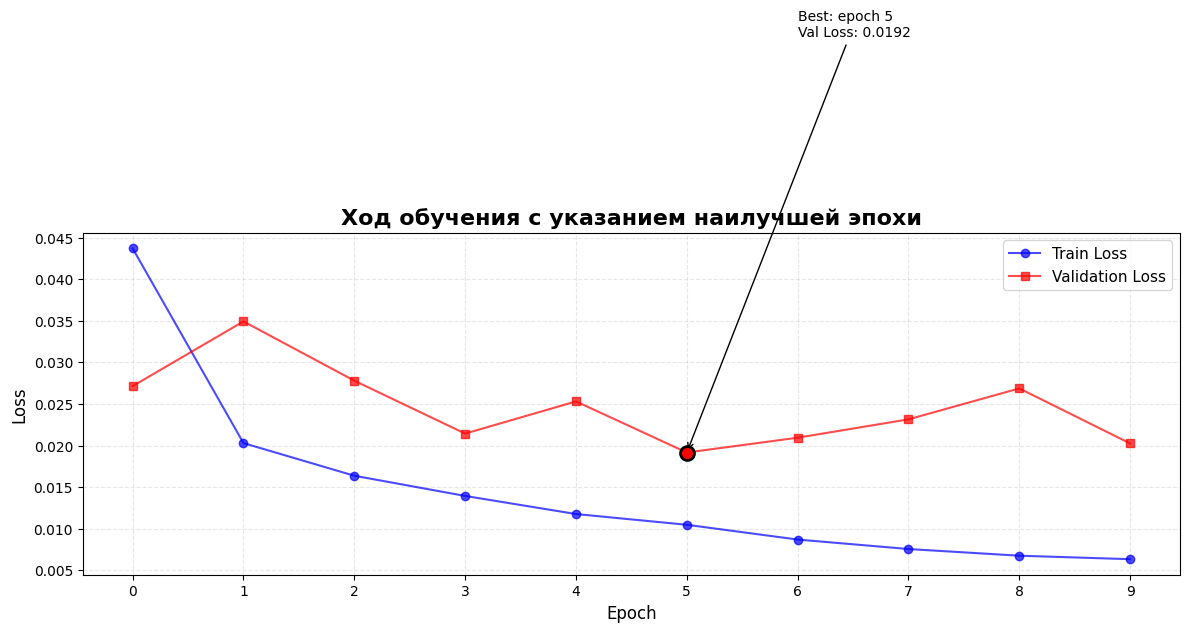

Лучшая эпоха: 5
Минимальная валидационная потеря: 0.0192


In [ ]:
chart_modern_plot(df_model_ResNet_18)